# Breed Dog Image Classification using AWS Sagemaker

### Project Description
This project focuses on solving a complex computer vision problem: identifying dog breeds from images. With over 130 breeds in the dataset, the challenge lies in capturing fine-grained visual features that distinguish highly similar breeds (low inter-class variation) while handling various poses and backgrounds (high intra-class variation). The solution is built as an end-to-end Machine Learning pipeline using Amazon SageMaker.

### Project Objective
The primary goal is to develop a highly accurate image classification model using Transfer Learning. By leveraging a pre-trained ResNet50 architecture, the project aims to minimize computational costs and training time while achieving professional-grade performance in breed identification. The final model is deployed to a real-time SageMaker Endpoint for scalable inference.

### Tools and Technologies
1. Cloud Platform: Amazon Web Services (AWS).

2. Machine Learning Service: Amazon SageMaker (Training Jobs, Hyperparameter Tuning, Endpoints).

3. Deep Learning Framework: PyTorch (v1.8+).

4. Model Architecture: ResNet50 (Pre-trained on ImageNet).

5. Monitoring & Logging: SageMaker Debugger and Profiler.

6. Programming Language: Python 3.

### Training Strategy
The training workflow follows a rigorous MLOps lifecycle divided into three main stages:

- Data Preparation: Images are organized into S3 channels and preprocessed using PyTorch transforms, including Data Augmentation (rotation, flipping, and color jittering) to improve model generalization.

- Hyperparameter Optimization (HPO): A dedicated tuning job (hpo.py) executes multiple trials to find the optimal combination of Learning Rate and Batch Size by monitoring the Validation Loss.

- Fine-Tuning & Monitoring: The best hyperparameters are used in a final training job (train_model.py). This stage integrates SageMaker Debugger to monitor gradients and Profiler to analyze hardware utilization, ensuring the model trains efficiently without overfitting.

In [1]:
# Install any packages that you might need
# For instance, you will need the smdebug package
!pip install opencv-python
!pip install "smdebug" "protobuf<=3.20.3" "bokeh<3.0.0"

In [2]:
import numpy as np

# SOLUCIÓN CRÍTICA: Parcheamos numpy para evitar el error de smdebug
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import os
import sys

# SOLUCIÓN CRÍTICA: Forzamos la implementación de Protobuf en Python 
# para evitar el error "Descriptors cannot be created directly"
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

# Parcheamos Bokeh para evitar el error 'plot_height' en TimelineCharts
import bokeh.plotting
if not hasattr(bokeh.plotting.Figure, 'plot_height'):
    bokeh.plotting.Figure.plot_height = property(lambda self: self.height, 
                                                lambda self, val: setattr(self, 'height', val))

In [3]:
# Import any packages that you might need
# For instance you will need Boto3 and Sagemaker
import sagemaker
import boto3
import numpy as np
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sagemaker.pytorch import PyTorch
import sagemaker

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


## Dataset
### Overview
The dataset used for this project is a comprehensive collection of dog images categorized by breed. It is a popular benchmark in the computer vision community for fine-grained image classification. Unlike general classification tasks (e.g., distinguishing between a car and a dog), this dataset requires the model to identify subtle morphological differences between closely related canine subspecies.

### Dataset Statistics
- Total Number of Classes: 133 distinct dog breeds (e.g., Affenpinscher, Airedale Terrier, Chihuahua, etc.).

- Data Split: The images are physically partitioned into three subsets to ensure a robust evaluation:

- Training Set: Used for the model to learn visual features.

- Validation Set: Used during Hyperparameter Tuning (HPO) to select the best model configuration and prevent overfitting.

- Test Set: Reserved for final evaluation to measure the model's true generalization capability on unseen data.

- Total Size: Approximately 1.15 GB of image data.

In [4]:
#TODO: Fetch and upload the data to AWS S3
# Command to download and unzip data
!wget https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
!unzip -o dogImages.zip
current_path = os.getcwd()
train_path = os.path.join(current_path, 'dogImages/train')
val_path = os.path.join(current_path, 'dogImages/valid')
test_path = os.path.join(current_path, 'dogImages/test')
train_labels = os.listdir(train_path)
valid_labels = os.listdir(val_path)
test_labels = os.listdir(test_path)
print(len(train_labels))
print(len(valid_labels))
print(len(test_labels))

--2026-03-25 13:28:41--  https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
Resolving s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)... 52.219.194.80, 52.219.112.144, 52.219.116.200, ...
Connecting to s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)|52.219.194.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1132023110 (1.1G) [application/zip]
Saving to: ‘dogImages.zip’

dogImages.zip       100%[===================>]   1.05G  22.9MB/s    in 27s     

2026-03-25 13:29:09 (39.5 MB/s) - ‘dogImages.zip’ saved [1132023110/1132023110]

Archive:  dogImages.zip
   creating: dogImages/
   creating: dogImages/test/
   creating: dogImages/train/
   creating: dogImages/valid/
   creating: dogImages/test/001.Affenpinscher/
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00003.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00023.jpg  
  inflating: dogImages/test/001.Affenpinscher/Affenpinscher_00036.jpg

In [5]:
from collections import defaultdict

limit = 20
def count_images_per_class(directory):
    counts = {}
    for label in os.listdir(directory):
        label_path = os.path.join(directory, label)
        if os.path.isdir(label_path):
            counts[label] = len(os.listdir(label_path))
    return counts

train_counts = count_images_per_class(train_path)
val_counts = count_images_per_class(val_path)
test_counts = count_images_per_class(test_path)
for label in list(train_counts.keys())[:limit]:
    print(f"Clase: {label}, Train: {train_counts[label]}, Val: {val_counts.get(label, 0)}, Test: {test_counts.get(label, 0)}")

Clase: 001.Affenpinscher, Train: 64, Val: 8, Test: 8
Clase: 002.Afghan_hound, Train: 58, Val: 7, Test: 8
Clase: 003.Airedale_terrier, Train: 52, Val: 7, Test: 6
Clase: 004.Akita, Train: 63, Val: 8, Test: 8
Clase: 005.Alaskan_malamute, Train: 77, Val: 9, Test: 10
Clase: 006.American_eskimo_dog, Train: 64, Val: 8, Test: 8
Clase: 007.American_foxhound, Train: 50, Val: 6, Test: 7
Clase: 008.American_staffordshire_terrier, Train: 66, Val: 8, Test: 8
Clase: 009.American_water_spaniel, Train: 34, Val: 4, Test: 4
Clase: 010.Anatolian_shepherd_dog, Train: 50, Val: 6, Test: 6
Clase: 011.Australian_cattle_dog, Train: 66, Val: 8, Test: 9
Clase: 012.Australian_shepherd, Train: 66, Val: 8, Test: 9
Clase: 013.Australian_terrier, Train: 46, Val: 6, Test: 6
Clase: 014.Basenji, Train: 69, Val: 8, Test: 9
Clase: 015.Basset_hound, Train: 73, Val: 9, Test: 10
Clase: 016.Beagle, Train: 59, Val: 7, Test: 8
Clase: 017.Bearded_collie, Train: 62, Val: 7, Test: 8
Clase: 018.Beauceron, Train: 50, Val: 6, Test: 7


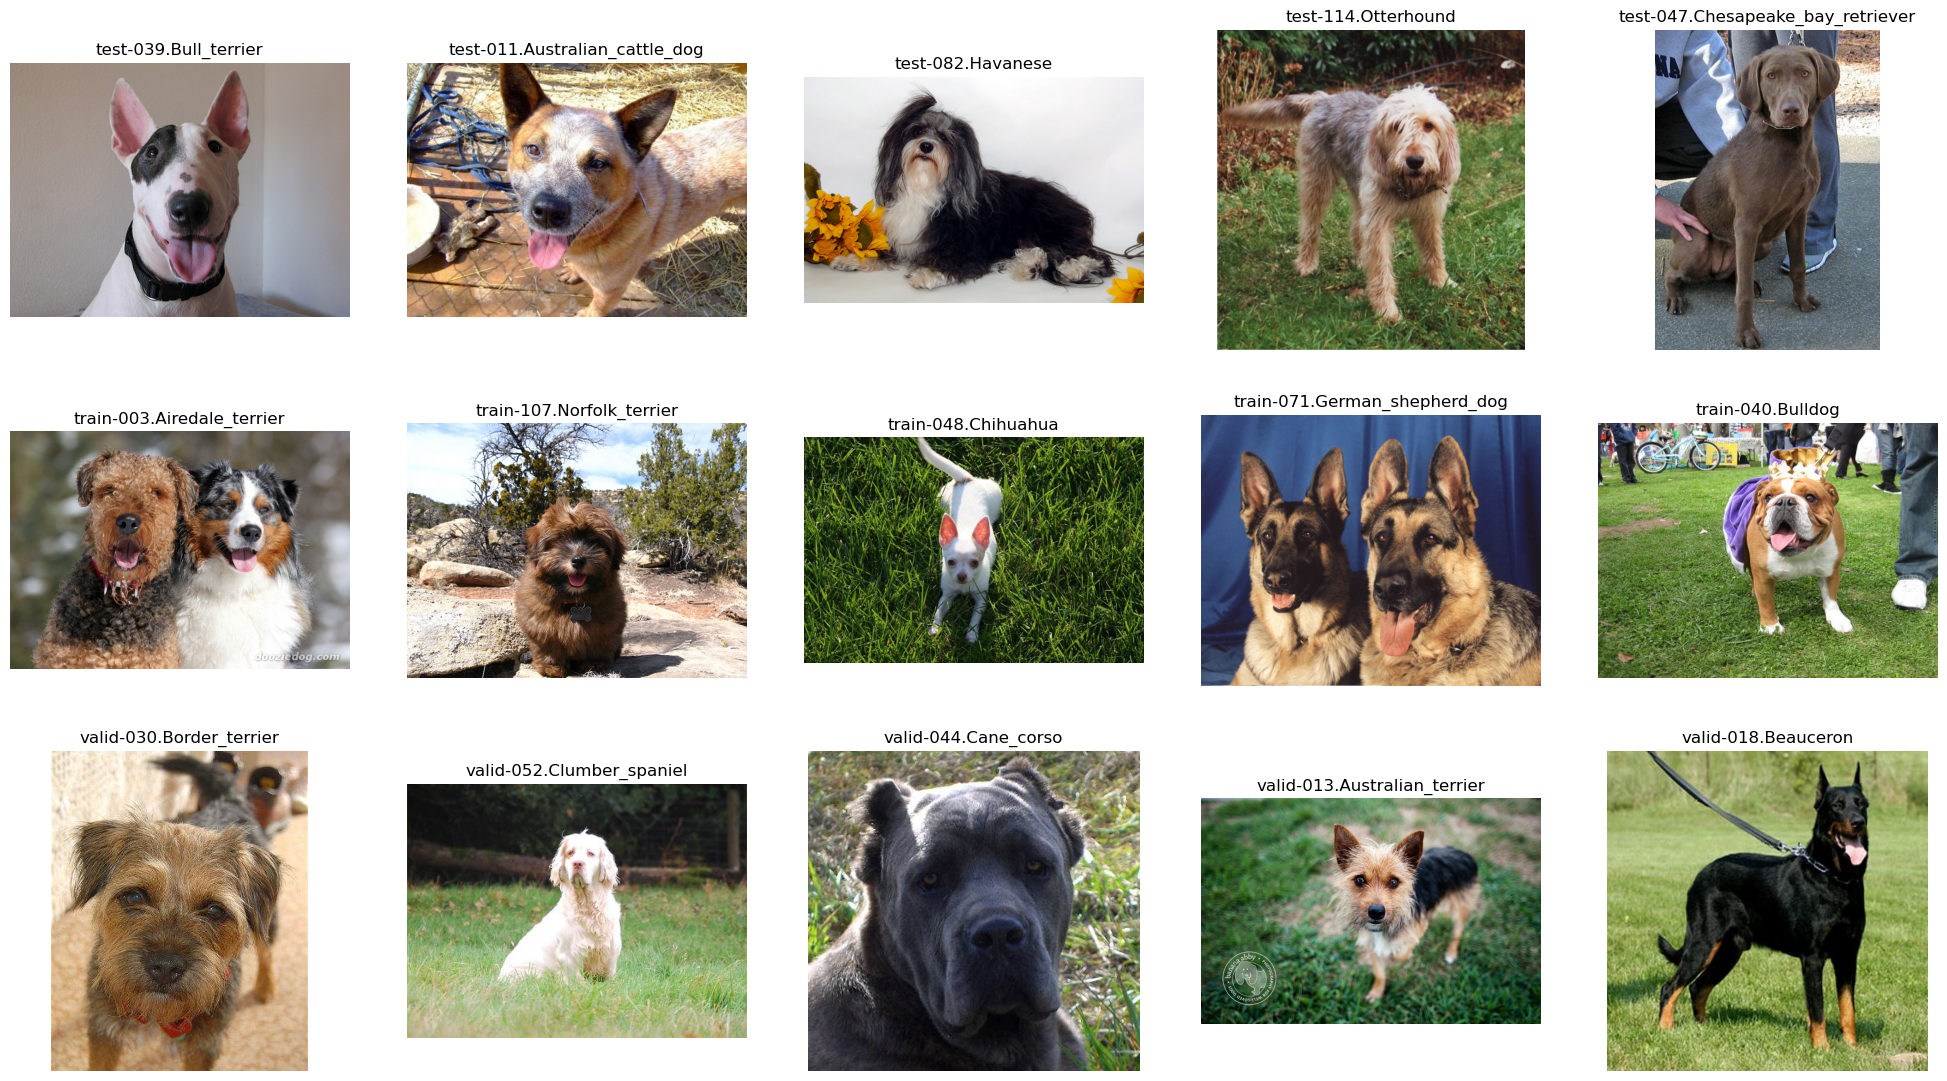

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import random
BASE_FOLDER = os.path.join(current_path, 'dogImages')
dataSets = os.listdir(BASE_FOLDER)
num_datasets = len(dataSets)
fig, axes = plt.subplots(num_datasets, 5, figsize=(20, 4*num_datasets))
fig.tight_layout()
plt.subplots_adjust(top=0.9)
for i, dataset in enumerate(dataSets):
    folders = os.listdir(os.path.join(BASE_FOLDER, dataset))
    for j in range(5):
        folder = random.choice(folders)
        files = os.listdir(os.path.join(BASE_FOLDER, dataset, folder))
        img_path = os.path.join(BASE_FOLDER, dataset, folder, random.choice(files))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if num_datasets > 1:
            axes[i, j].imshow(img)
            axes[i, j].set_title(f'{dataset}-{folder}')
            axes[i, j].axis('off')
        else:
            axes[j].imshow(img)
            axes[j].set_title(f'{dataset}-{folder}')
            axes[j].axis('off')

plt.show()

Folder /home/sagemaker-user/udacity-aws-ml-nanodegree/breed-dog-image-classification-pjt/dogImages/test Total Classes: 133
Examples of classes: ['001.Affenpinscher', '002.Afghan_hound', '003.Airedale_terrier', '004.Akita', '005.Alaskan_malamute', '006.American_eskimo_dog', '007.American_foxhound', '008.American_staffordshire_terrier', '009.American_water_spaniel', '010.Anatolian_shepherd_dog']
Total images: 836
Folder /home/sagemaker-user/udacity-aws-ml-nanodegree/breed-dog-image-classification-pjt/dogImages/train Total Classes: 133
Examples of classes: ['001.Affenpinscher', '002.Afghan_hound', '003.Airedale_terrier', '004.Akita', '005.Alaskan_malamute', '006.American_eskimo_dog', '007.American_foxhound', '008.American_staffordshire_terrier', '009.American_water_spaniel', '010.Anatolian_shepherd_dog']
Total images: 6680
Folder /home/sagemaker-user/udacity-aws-ml-nanodegree/breed-dog-image-classification-pjt/dogImages/valid Total Classes: 133
Examples of classes: ['001.Affenpinscher', '

<Figure size 1200x600 with 0 Axes>

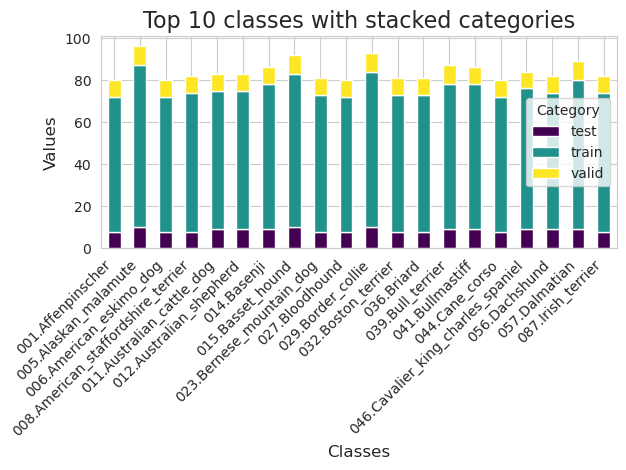

-----------------------------------------------------------------


Difference between categories test-train: 
0
Difference between categories val-train: 
0


In [7]:
import cv2
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

def inspect_dataset(data_dir: list):
  data={}
  for dir in data_dir:

    class_names = os.listdir(dir)
    num_classes = len(class_names)
    print(f"Folder {dir} Total Classes: {num_classes}")
    # show examples of classes
    print(f"Examples of classes: {class_names[:10]}")

    # count images per class
    class_counts = {}
    total_images = 0
    for class_name in class_names:
      class_dir = os.path.join(dir, class_name)
      if os.path.isdir(dir):
          img_count = len(os.listdir(class_dir))
          class_counts[class_name] = img_count
          total_images += img_count
    print(f"Total images: {total_images}")
    data[dir]=class_counts

  data_list = []
  for category, clases in data.items():
    path_category = Path(category)
    last_folder = path_category.name
    for class_label, value in clases.items():
        data_list.append({
            'Category': last_folder,
            'Class': class_label,
            'Value': value
        })
  # Create a dataframe
  df = pd.DataFrame(data_list)

  # Sum the values per class and get the top 10 classes
  valores_por_clase = df.groupby('Class')['Value'].sum().reset_index()
  top10_clases = valores_por_clase.sort_values('Value', ascending=False).head(20)['Class'].tolist()

  # Filtrar el DataFrame para incluir solo las top 10 clases
  df_top10 = df[df['Class'].isin(top10_clases)]

  # Pivot the DataFrame to have categories as columns and classes as index
  df_ancho = df_top10.pivot(index='Class', columns='Category', values='Value')

  # Create figure
  plt.figure(figsize=(12, 6))
  sns.set_style("whitegrid")

  # stacked bar plot
  df_ancho.plot(kind='bar', stacked=True, colormap='viridis')

  # Customize the plot
  plt.title('Top 10 classes with stacked categories', fontsize=16)
  plt.xlabel('Classes', fontsize=12)
  plt.ylabel('Values', fontsize=12)
  plt.xticks(rotation=45, ha='right')
  plt.legend(title='Category')

  # Ajustar el diseño y mostrar la gráfica
  plt.tight_layout()
  plt.show()
  return class_names, num_classes

inspect_dataset([test_path,train_path,val_path])


print('-----------------------------------------------------------------\n\n')
print('Difference between categories test-train: ')
print(len(set(test_labels).difference(train_labels)))
print('Difference between categories val-train: ')
print(len(set(valid_labels).difference(train_labels)))

In [8]:
sagemaker_session = sagemaker.Session()
role = sagemaker.get_execution_role()

In [9]:
bucket = sagemaker_session.default_bucket()
# 3. The prefix (the folder in S3 where the data will be stored)
prefix_base = 'dog-breed-classification'
prefix = f'{prefix_base}/data'

# 4. Local path where you have the dataset unzipped
local_data_path = './dogImages'

print(f"Uploading data to S3: s3://{bucket}/{prefix}...")

s3_data_uri = sagemaker_session.upload_data(
    path=local_data_path,
    bucket=bucket,
    key_prefix=prefix
)

print(f"Upload complete. S3 URI for Training Jobs: {s3_data_uri}")

Uploading data to S3: s3://sagemaker-us-east-1-697682206292/dog-breed-classification/data...
Upload complete. S3 URI for Training Jobs: s3://sagemaker-us-east-1-697682206292/dog-breed-classification/data


## Hyperparameter Tuning
**TODO:** This is the part where you will finetune a pretrained model with hyperparameter tuning. Remember that you have to tune a minimum of two hyperparameters. However you are encouraged to tune more. You are also encouraged to explain why you chose to tune those particular hyperparameters and the ranges.

**Note:** You will need to use the `hpo.py` script to perform hyperparameter tuning.

In [ ]:
#TODO: Declare your HP ranges, metrics etc.
import sagemaker
from sagemaker.tuner import (
    IntegerParameter,
    CategoricalParameter,
    ContinuousParameter,
    HyperparameterTuner,
)

hyperparameter_ranges = {
    "lr": ContinuousParameter(0.001, 0.1),
    "batch_size": CategoricalParameter([32, 64, 128, 256, 512]),
}

objective_metric_name = "average test loss"
objective_type = "Minimize"
metric_definitions = [{"Name": "average test loss", "Regex": "Test set: Average loss: ([0-9\\.]+)"}]

In [11]:
from sagemaker.pytorch import PyTorch

estimator = PyTorch(
    entry_point="hpo.py",
    source_dir="code",
    base_job_name="pytorch-hpo-dog-breed-classification",
    role=role,
    py_version='py38',
    framework_version="1.9",
    instance_count=1,
    instance_type="ml.m5.2xlarge"
)

tuner = HyperparameterTuner(
    estimator,
    objective_metric_name,
    hyperparameter_ranges,
    metric_definitions,
    max_jobs=4,
    max_parallel_jobs=2,
    base_tuning_job_name = 'pytorch-dog-breed-hpo-tuning',
    objective_type=objective_type,
)

In [12]:
# TODO: Fit your HP Tuner
tuner.fit({"data": s3_data_uri}, wait=True)

No finished training job found associated with this estimator. Please make sure this estimator is only used for building workflow config


..........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................!


In [13]:
tuner.describe()

{'HyperParameterTuningJobName': 'pytorch-dog-breed-hp-260325-1339',
 'HyperParameterTuningJobArn': 'arn:aws:sagemaker:us-east-1:697682206292:hyper-parameter-tuning-job/pytorch-dog-breed-hp-260325-1339',
 'HyperParameterTuningJobConfig': {'Strategy': 'Bayesian',
  'HyperParameterTuningJobObjective': {'Type': 'Minimize',
   'MetricName': 'average test loss'},
  'ResourceLimits': {'MaxNumberOfTrainingJobs': 4,
   'MaxParallelTrainingJobs': 2},
  'ParameterRanges': {'IntegerParameterRanges': [],
   'ContinuousParameterRanges': [{'Name': 'lr',
     'MinValue': '0.001',
     'MaxValue': '0.1',
     'ScalingType': 'Auto'}],
   'CategoricalParameterRanges': [{'Name': 'batch_size',
     'Values': ['"32"', '"64"', '"128"', '"256"', '"512"']}]},
  'TrainingJobEarlyStoppingType': 'Off'},
 'TrainingJobDefinition': {'StaticHyperParameters': {'_tuning_objective_metric': 'average test loss',
   'sagemaker_container_log_level': '20',
   'sagemaker_estimator_class_name': '"PyTorch"',
   'sagemaker_estim

In [14]:
tuner.best_training_job()

'pytorch-dog-breed-hp-260325-1339-003-f8f1552e'

In [15]:
# Get the best estimators and the best HPs
best_estimator = tuner.best_estimator()

#Get the hyperparameters of the best trained model
best_hyperparameters = best_estimator.hyperparameters()


2026-03-25 14:20:18 Starting - Found matching resource for reuse
2026-03-25 14:20:18 Downloading - Downloading the training image
2026-03-25 14:20:18 Training - Training image download completed. Training in progress.
2026-03-25 14:20:18 Uploading - Uploading generated training model
2026-03-25 14:20:18 Completed - Resource released due to keep alive period expiry


In [16]:
best_hyperparameters

{'_tuning_objective_metric': '"average test loss"',
 'batch_size': '"32"',
 'lr': '0.0025278486685455753',
 'sagemaker_container_log_level': '20',
 'sagemaker_estimator_class_name': '"PyTorch"',
 'sagemaker_estimator_module': '"sagemaker.pytorch.estimator"',
 'sagemaker_job_name': '"pytorch-hpo-dog-breed-classification-2026-03-25-13-39-21-908"',
 'sagemaker_program': '"hpo.py"',
 'sagemaker_region': '"us-east-1"',
 'sagemaker_submit_directory': '"s3://sagemaker-us-east-1-697682206292/pytorch-hpo-dog-breed-classification-2026-03-25-13-39-21-908/source/sourcedir.tar.gz"'}

In [17]:
tuner.analytics().dataframe()

,batch_size,lr,TrainingJobName,TrainingJobStatus,FinalObjectiveValue,TrainingStartTime,TrainingEndTime,TrainingElapsedTimeSeconds
0,"""512""",0.052565,pytorch-dog-breed-hp-260325-1339-004-29005a08,Completed,37.368999,2026-03-25 14:03:24+00:00,2026-03-25 14:25:24+00:00,1320.0
1,"""32""",0.002528,pytorch-dog-breed-hp-260325-1339-003-f8f1552e,Completed,0.981200,2026-03-25 14:01:12+00:00,2026-03-25 14:20:16+00:00,1144.0
2,"""256""",0.012270,pytorch-dog-breed-hp-260325-1339-002-58f3b7d8,Completed,1.272200,2026-03-25 13:40:17+00:00,2026-03-25 14:02:30+00:00,1333.0
3,"""32""",0.002459,pytorch-dog-breed-hp-260325-1339-001-fcdc3a19,Completed,1.106300,2026-03-25 13:40:08+00:00,2026-03-25 13:59:42+00:00,1174.0


In [18]:
best_hyperparameter_params = {
    "lr": best_hyperparameters["lr"],
    "batch_size": best_hyperparameters["batch_size"].replace('"', '')
}

In [19]:
best_hyperparameter_params

{'lr': '0.0025278486685455753', 'batch_size': '32'}

## Model Profiling and Debugging
TODO: Using the best hyperparameters, create and finetune a new model

**Note:** You will need to use the `train_model.py` script to perform model profiling and debugging.

In [20]:
# adding epochs to the best hyperparameters
best_hyperparameter_params["epochs"] = 20

In [21]:
best_hyperparameter_params

{'lr': '0.0025278486685455753', 'batch_size': '32', 'epochs': 20}

In [22]:
# TODO: Set up debugging and profiling rules and hooks
from sagemaker.debugger import DebuggerHookConfig, CollectionConfig
from sagemaker.debugger import (
    Rule,
    rule_configs,
    ProfilerRule,
    DebuggerHookConfig,
    ProfilerConfig,
    FrameworkProfile
    )


rules = [
    ProfilerRule.sagemaker(rule_configs.LowGPUUtilization()),
    ProfilerRule.sagemaker(rule_configs.ProfilerReport()),
    Rule.sagemaker(rule_configs.vanishing_gradient()),
    Rule.sagemaker(rule_configs.overfit()),
    Rule.sagemaker(rule_configs.overtraining()),
    Rule.sagemaker(rule_configs.poor_weight_initialization()),
]

profiler_config = ProfilerConfig(
    system_monitor_interval_millis=500, framework_profile_params=FrameworkProfile(num_steps=10)
)

debugger_config = DebuggerHookConfig(
    hook_parameters={
        "train.save_interval": "100", 
        "eval.save_interval": "10"
    }
)
output_location = f's3://{bucket}/{prefix_base}/output/'

Framework profiling will be deprecated from tensorflow 2.12 and pytorch 2.0 in sagemaker>=2.
See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


In [23]:
metric_definitions = [
    # loss - training
    {"Name": "train:loss", "Regex": "Phase train - Loss: ([0-9\\.]+)"},
    
    # accuracy - training
    {"Name": "train:accuracy", "Regex": "Phase train - Loss: [0-9\\.]+ Acc: ([0-9\\.]+)"},
    
    # loss - validation
    {"Name": "validation:loss", "Regex": "Phase valid - Loss: ([0-9\\.]+)"},
    
    # accuracy - validation
    {"Name": "validation:accuracy", "Regex": "Phase valid - Loss: [0-9\\.]+ Acc: ([0-9\\.]+)"}
]

In [24]:
estimator = PyTorch(
    role = role,
    instance_count = 1,
    instance_type = "ml.p3.2xlarge",
    entry_point = "train_model.py",
    source_dir = "code",
    base_job_name = "smdebugger-train-dog-breed-class-pytorch",
    framework_version = "1.9",
    py_version = "py38",
    output_location = output_location,
    hyperparameters = best_hyperparameter_params,
    debugger_hook_config = debugger_config,
    profiler_config = profiler_config,
    metric_definitions = metric_definitions,
    rules = rules
)

estimator.fit({"data": s3_data_uri}, wait=True)

INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642


2026-03-25 14:30:42 Starting - Starting the training job...
2026-03-25 14:31:07 Pending - Training job waiting for capacityVanishingGradient: InProgress
Overfit: InProgress
Overtraining: InProgress
PoorWeightInitialization: InProgress
LowGPUUtilization: InProgress
ProfilerReport: InProgress
...
2026-03-25 14:31:35 Pending - Preparing the instances for training...
2026-03-25 14:32:15 Downloading - Downloading input data......
2026-03-25 14:33:16 Downloading - Downloading the training image........................
2026-03-25 14:37:17 Training - Training image download completed. Training in progress....bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2026-03-25 14:37:32,232 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2026-03-25 14:37:32,262 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2026-03-25 14:37:32,265 sagemaker_pytorch_container.

In [25]:
import boto3

session = boto3.session.Session()
region = session.region_name

training_job_name = estimator.latest_training_job.name
print(f"Training jobname: {training_job_name}\n")
print(f"Debugger output path: {estimator.latest_job_debugger_artifacts_path()}\n")
print(f"Region: {region}\n")
print("rule_output_path : {}\n".format(estimator.output_path + estimator.latest_training_job.job_name + "/rule-output"))

Training jobname: smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642

Debugger output path: s3://sagemaker-us-east-1-697682206292/smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/debug-output

Region: us-east-1

rule_output_path : s3://sagemaker-us-east-1-697682206292/smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output



In [26]:
# TODO: Plot a debugging output.
from smdebug.trials import create_trial
from smdebug.core.modes import ModeKeys

trial = create_trial(estimator.latest_job_debugger_artifacts_path())

[2026-03-25 14:49:52.405 default:562 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-03-25 14:49:52.588 default:562 INFO s3_trial.py:42] Loading trial debug-output at path s3://sagemaker-us-east-1-697682206292/smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/debug-output


In [27]:
print(trial.tensor_names())

[2026-03-25 14:49:56.301 default:562 INFO trial.py:197] Training has ended, will refresh one final time in 1 sec.
[2026-03-25 14:49:57.321 default:562 INFO trial.py:210] Loaded all steps
['CrossEntropyLoss_output_0', 'gradient/ResNet_fc.0.bias', 'gradient/ResNet_fc.0.weight', 'layer1.0.relu_input_0', 'layer1.0.relu_input_1', 'layer1.0.relu_input_2', 'layer1.1.relu_input_0', 'layer1.1.relu_input_1', 'layer1.1.relu_input_2', 'layer1.2.relu_input_0', 'layer1.2.relu_input_1', 'layer1.2.relu_input_2', 'layer2.0.relu_input_0', 'layer2.0.relu_input_1', 'layer2.0.relu_input_2', 'layer2.1.relu_input_0', 'layer2.1.relu_input_1', 'layer2.1.relu_input_2', 'layer2.2.relu_input_0', 'layer2.2.relu_input_1', 'layer2.2.relu_input_2', 'layer2.3.relu_input_0', 'layer2.3.relu_input_1', 'layer2.3.relu_input_2', 'layer3.0.relu_input_0', 'layer3.0.relu_input_1', 'layer3.0.relu_input_2', 'layer3.1.relu_input_0', 'layer3.1.relu_input_1', 'layer3.1.relu_input_2', 'layer3.2.relu_input_0', 'layer3.2.relu_input_1'

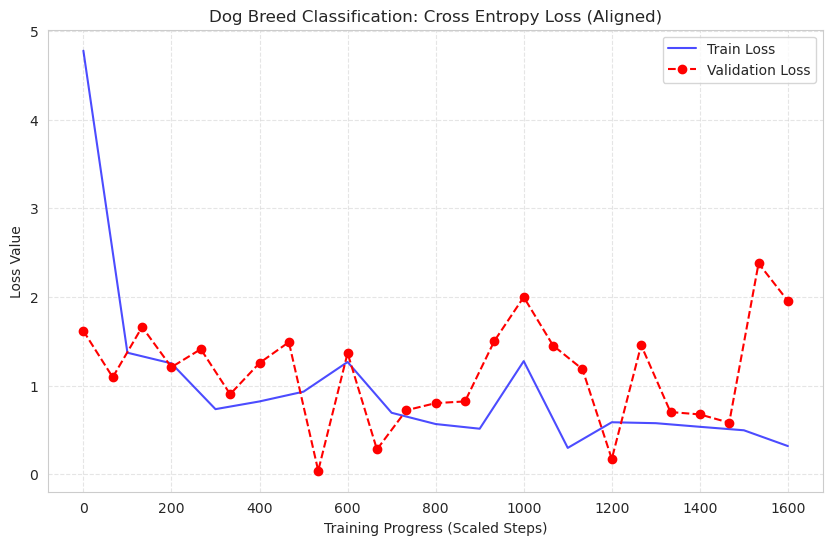

In [44]:
import matplotlib.pyplot as plt
from smdebug.core.modes import ModeKeys

def plot_loss_evolution(trial):
    # 1. Extraemos los pasos (eje X) y los valores (eje Y)
    tensor = trial.tensor("CrossEntropyLoss_output_0")
    
    train_steps = tensor.steps(mode=ModeKeys.TRAIN)
    train_values = list(tensor.values(mode=ModeKeys.TRAIN).values())
    
    val_steps = tensor.steps(mode=ModeKeys.EVAL)
    val_values = list(tensor.values(mode=ModeKeys.EVAL).values())
    
    # 2. SOLUCIÓN: Calculamos un factor de escala para estirar la línea de validación
    # y que termine exactamente donde termina la de entrenamiento.
    max_train = max(train_steps)
    max_val = max(val_steps) if len(val_steps) > 0 else 1
    scale_factor = max_train / max_val
    
    # Estiramos los pasos de validación
    val_steps_scaled = [s * scale_factor for s in val_steps]

    # 3. Dibujamos la gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(train_steps, train_values, label="Train Loss", color="blue", alpha=0.7)
    
    # Usamos los pasos escalados para la validación
    plt.plot(val_steps_scaled, val_values, label="Validation Loss", color="red", marker="o", linestyle="--")
    
    plt.title("Dog Breed Classification: Cross Entropy Loss (Aligned)")
    plt.xlabel("Training Progress (Scaled Steps)")
    plt.ylabel("Loss Value")
    plt.legend()
    plt.grid(linestyle="--", alpha=0.5)
    plt.show()

# Ejecuta tu función
plot_loss_evolution(trial)

In [28]:
def get_data(trial, tname, mode):
    tensor = trial.tensor(tname)
    steps = tensor.steps(mode=mode)
    vals = []
    for s in steps:
        vals.append(tensor.value(s, mode=mode))
    return steps, vals

In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import host_subplot


def plot_tensor(trial, tensor_name):

    steps_train, vals_train = get_data(trial, tensor_name, mode=ModeKeys.TRAIN)
    print("loaded TRAIN data")
    steps_eval, vals_eval = get_data(trial, tensor_name, mode=ModeKeys.EVAL)
    print("loaded EVAL data")

    fig = plt.figure(figsize=(10, 7))
    host = host_subplot(111)

    par = host.twiny()

    host.set_xlabel("Steps (TRAIN)")
    par.set_xlabel("Steps (EVAL)")
    host.set_ylabel(tensor_name)

    (p1,) = host.plot(steps_train, vals_train, label=tensor_name)
    print("completed TRAIN plot")
    (p2,) = par.plot(steps_eval, vals_eval, label="val_" + tensor_name)
    print("completed EVAL plot")
    leg = plt.legend()

    host.xaxis.get_label().set_color(p1.get_color())
    leg.texts[0].set_color(p1.get_color())

    par.xaxis.get_label().set_color(p2.get_color())
    leg.texts[1].set_color(p2.get_color())

    plt.ylabel(tensor_name)

    plt.show()

loaded TRAIN data
loaded EVAL data
completed TRAIN plot
completed EVAL plot


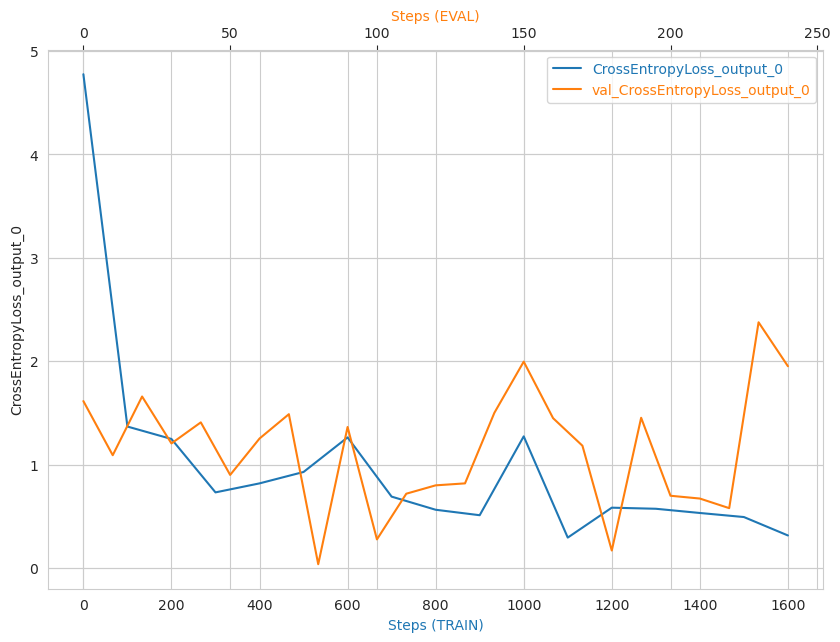

In [30]:
plot_tensor(trial, "CrossEntropyLoss_output_0")

In [31]:
from smdebug.profiler.analysis.notebook_utils.training_job import TrainingJob

tj = TrainingJob(training_job_name, region)
tj.wait_for_sys_profiling_data_to_be_available()

ProfilerConfig:{'S3OutputPath': 's3://sagemaker-us-east-1-697682206292/', 'ProfilingIntervalInMilliseconds': 500, 'ProfilingParameters': {'DataloaderProfilingConfig': '{"StartStep": 0, "NumSteps": 10, "MetricsRegex": ".*", }', 'DetailedProfilingConfig': '{"StartStep": 0, "NumSteps": 10, }', 'FileOpenFailThreshold': '50', 'HorovodProfilingConfig': '{"StartStep": 0, "NumSteps": 10, }', 'LocalPath': '/opt/ml/output/profiler', 'PythonProfilingConfig': '{"StartStep": 0, "NumSteps": 10, "ProfilerName": "cprofile", "cProfileTimer": "total_time", }', 'RotateFileCloseIntervalInSeconds': '60', 'RotateMaxFileSizeInBytes': '10485760', 'SMDataParallelProfilingConfig': '{"StartStep": 0, "NumSteps": 10, }'}, 'DisableProfiler': False}
s3 path:s3://sagemaker-us-east-1-697682206292/smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/profiler-output


Profiler data from system is available


**TODO**: Is there some anomalous behaviour in your debugging output? If so, what is the error and how will you fix it?  
**TODO**: If not, suppose there was an error. What would that error look like and how would you have fixed it?

In [32]:
# TODO: Display the profiler output
from smdebug.profiler.analysis.notebook_utils.timeline_charts import TimelineCharts
system_metrics_reader = tj.get_systems_metrics_reader()
system_metrics_reader.refresh_event_file_list()

view_timeline_charts = TimelineCharts(
    system_metrics_reader,
    framework_metrics_reader=None,
    select_dimensions=["CPU", "GPU"],
    select_events=["total"],
)

[2026-03-25 14:50:54.218 default:562 INFO metrics_reader_base.py:134] Getting 18 event files
select events:['total']
select dimensions:['CPU', 'GPU']
filtered_events:{'total'}
filtered_dimensions:{'GPUMemoryUtilization-nodeid:algo-1', 'GPUUtilization-nodeid:algo-1', 'CPUUtilization-nodeid:algo-1'}


In [33]:
rule_output_path = estimator.output_path + estimator.latest_training_job.job_name + "/rule-output"
print(f"You will find the profiler report in {rule_output_path}")

You will find the profiler report in s3://sagemaker-us-east-1-697682206292/smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output


In [34]:
! aws s3 ls {rule_output_path} --recursive

2026-03-25 14:49:40     405013 smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output/ProfilerReport/profiler-output/profiler-report.html
2026-03-25 14:49:40     258441 smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output/ProfilerReport/profiler-output/profiler-report.ipynb
2026-03-25 14:49:35        567 smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output/ProfilerReport/profiler-output/profiler-reports/BatchSize.json
2026-03-25 14:49:35      26784 smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output/ProfilerReport/profiler-output/profiler-reports/CPUBottleneck.json
2026-03-25 14:49:35       2423 smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output/ProfilerReport/profiler-output/profiler-reports/Dataloader.json
2026-03-25 14:49:35        130 smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output/ProfilerReport/profiler-output/profiler-reports/GPUMemoryIn

In [35]:
! aws s3 cp {rule_output_path} ./ --recursive

download: s3://sagemaker-us-east-1-697682206292/smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output/ProfilerReport/profiler-output/profiler-report.ipynb to ProfilerReport/profiler-output/profiler-report.ipynb
download: s3://sagemaker-us-east-1-697682206292/smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output/ProfilerReport/profiler-output/profiler-reports/GPUMemoryIncrease.json to ProfilerReport/profiler-output/profiler-reports/GPUMemoryIncrease.json
download: s3://sagemaker-us-east-1-697682206292/smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output/ProfilerReport/profiler-output/profiler-report.html to ProfilerReport/profiler-output/profiler-report.html
download: s3://sagemaker-us-east-1-697682206292/smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/rule-output/ProfilerReport/profiler-output/profiler-reports/BatchSize.json to ProfilerReport/profiler-output/profiler-reports/BatchSize.json
download: s3:/

In [36]:
import os

# get the autogenerated folder name of profiler report
profiler_report_name = [
    rule["RuleConfigurationName"]
    for rule in estimator.latest_training_job.rule_job_summary()
    if "Profiler" in rule["RuleConfigurationName"]
][0]

In [38]:
!pip install "smdebug==1.0.34" "protobuf<=3.20.3" "bokeh<3.0.0"

In [39]:
import IPython

IPython.display.HTML(filename=profiler_report_name + "/profiler-output/profiler-report.html")

## Model Deploying

In [40]:
from sagemaker.pytorch import PyTorchModel
import time


timestamp = time.strftime("%Y-%m-%d-%H-%M-%S", time.gmtime())
inference_endpoint_name = f"dog-breed-classifier-ep-{timestamp}"

# 1. Create model in SageMaker and inference script
pytorch_model = PyTorchModel(
    model_data=estimator.model_data,
    role=role,
    entry_point='inference.py',
    source_dir = "code",
    framework_version='1.9',
    py_version='py38'
)

# 2. Deploy endpoint
predictor = pytorch_model.deploy(
    initial_instance_count=1,
    instance_type='ml.m5.large',
    endpoint_name=inference_endpoint_name,
    serializer=sagemaker.serializers.IdentitySerializer(content_type="image/jpeg")
)

print(f"Endpoint desplegado en: {predictor.endpoint_name}")

INFO:sagemaker:Repacking model artifact (s3://sagemaker-us-east-1-697682206292/smdebugger-train-dog-breed-class-pytorc-2026-03-25-14-30-41-642/output/model.tar.gz), script artifact (code), and dependencies ([]) into single tar.gz file located at s3://sagemaker-us-east-1-697682206292/pytorch-inference-2026-03-25-14-54-03-204/model.tar.gz. This may take some time depending on model size...
INFO:sagemaker:Creating model with name: pytorch-inference-2026-03-25-14-54-17-360
INFO:sagemaker:Creating endpoint-config with name dog-breed-classifier-ep-2026-03-25-14-54-02
INFO:sagemaker:Creating endpoint with name dog-breed-classifier-ep-2026-03-25-14-54-02


-------!Endpoint desplegado en: dog-breed-classifier-ep-2026-03-25-14-54-02


In [41]:
import os

data_dir = "dogImages/train"
classes = sorted(os.listdir(data_dir))
dog_names = [cls.split('.')[-1].replace('_', ' ') for cls in classes]


Ground Truth: Affenpinscher


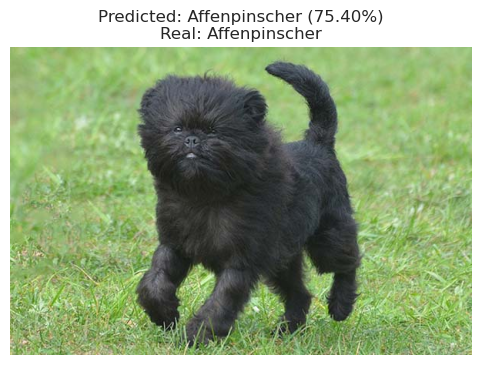

Result -> Prediction: Affenpinscher | Probability: 0.7540

Ground Truth: Chihuahua


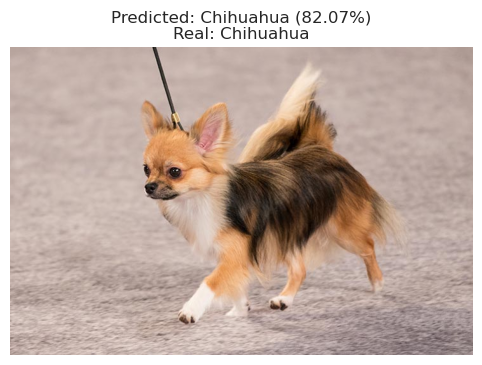

Result -> Prediction: Chihuahua | Probability: 0.8207

Ground Truth: Chow_chow


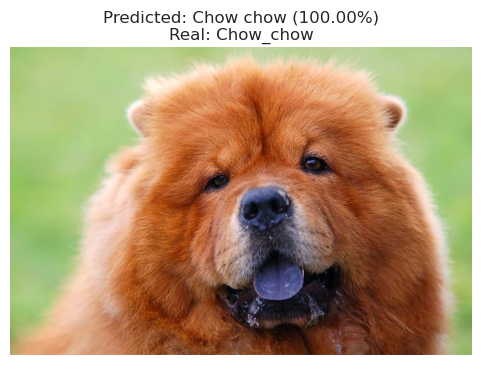

Result -> Prediction: Chow chow | Probability: 1.0000

Ground Truth: Beagle


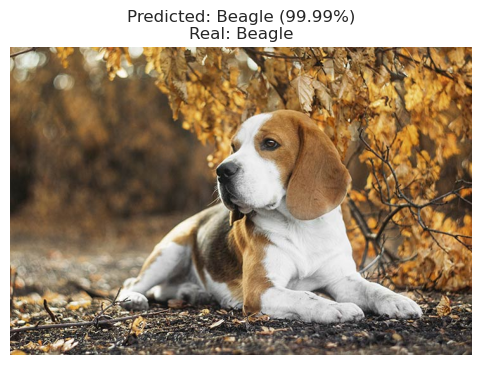

Result -> Prediction: Beagle | Probability: 0.9999

Ground Truth: Dalmatian


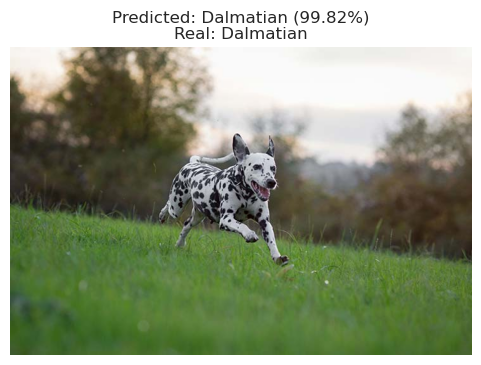

Result -> Prediction: Dalmatian | Probability: 0.9982


In [42]:
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def softmax(x):
    """softmax calculation."""
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def test_model_with_url(url, ground_truth):
    """
        Download image from URL, perform inference, and display results.
    """
    print(f"\nGround Truth: {ground_truth}")
    
    try:
        # 1. Download the image
        response_img = requests.get(url, timeout=10)
        if response_img.status_code != 200:
            print(f"Error in download: {url}")
            return
        
        image_bytes = response_img.content
        
        # 2. Inference
        # Execute predictor with IdentitySerializer(content_type="image/jpeg")
        response = predictor.predict(image_bytes, initial_args={"ContentType": "image/jpeg"})
        
        # 3. Processing logits and apply softmax
        logits = np.array(response[0])
        probabilities = softmax(logits)
        
        predicted_index = np.argmax(logits)
        predicted_name = dog_names[predicted_index]
        confidence = probabilities[predicted_index]
        
        # 4. Visualization
        img = Image.open(io.BytesIO(image_bytes))
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"Predicted: {predicted_name} ({confidence*100:.2f}%)\nReal: {ground_truth}")
        plt.axis('off')
        plt.show()
        
        # 5. Report
        print(f"Result -> Prediction: {predicted_name} | Probability: {confidence:.4f}")
        
    except Exception as e:
        print(f"Error in the test: {e}")

# --- SAMPLES ---
test_samples = [
    {
        "url": "https://www.akc.org/wp-content/uploads/2017/11/Affenpinscher-running-outdoors.jpg",
        "label": "Affenpinscher"
    },
    {
        "url": "https://www.akc.org/wp-content/uploads/2017/11/Chihuahua-at-the-AKC-National-Championship.jpg",
        "label": "Chihuahua"
    },
    {
        "url": "https://www.akc.org/wp-content/uploads/2018/04/chow-chow-closeup-portrait-drooling.jpg",
        "label": "Chow_chow"
    },
    {
        "url": "https://www.akc.org/wp-content/uploads/2017/11/Beagle-laying-down-in-the-shade-outdoors.jpg",
        "label": "Beagle"
    },
    {
        "url": "https://www.akc.org/wp-content/uploads/2017/11/Dalmatian-running-across-the-grass.jpg",
        "label": "Dalmatian"
    }
]

for sample in test_samples:
    test_model_with_url(sample['url'], sample['label'])

In [43]:
# TODO: Remember to shutdown/delete your endpoint once your work is done
predictor.delete_endpoint()

INFO:sagemaker:Deleting endpoint configuration with name: dog-breed-classifier-ep-2026-03-25-14-54-02
INFO:sagemaker:Deleting endpoint with name: dog-breed-classifier-ep-2026-03-25-14-54-02
